In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [5]:
df = pd.read_csv("~/PROJECT/Data_Cleaning_Visualization/data/big_retail_sales_dataset.csv")

In [7]:
# First 5 rows
df.head()

# Last 5 rows
df.tail()

# Shape
df.shape

# Column names
df.columns

# Data types
df.dtypes

# Dataset information
df.info()

# Statistical summary
df.describe()

# Statistical summary for all columns
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Order_ID        101000 non-null  int64  
 1   Customer_ID     101000 non-null  int64  
 2   Order_Date      101000 non-null  object 
 3   Category        97990 non-null   object 
 4   Region          101000 non-null  object 
 5   City            97971 non-null   object 
 6   Customer_Type   101000 non-null  object 
 7   Quantity        101000 non-null  int64  
 8   Sales           97970 non-null   float64
 9   Discount        101000 non-null  float64
 10  Profit          97967 non-null   float64
 11  Payment_Method  101000 non-null  object 
 12  Rating          101000 non-null  float64
dtypes: float64(4), int64(3), object(6)
memory usage: 10.0+ MB


,Order_ID,Customer_ID,Order_Date,Category,Region,City,Customer_Type,Quantity,Sales,Discount,Profit,Payment_Method,Rating
count,101000.000000,101000.00000,101000,97990,101000,97971,101000,101000.000000,97970.000000,101000.000000,97967.000000,101000,101000.000000
unique,NaN,NaN,730,12,6,10,3,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,2023-04-25,Furniture,Central,Delhi,Regular,NaN,NaN,NaN,NaN,Debit Card,NaN
freq,NaN,NaN,173,9800,20327,9967,33852,NaN,NaN,NaN,NaN,20287,NaN
mean,149997.857812,25425.76202,NaN,NaN,NaN,NaN,NaN,7.485505,12929.105187,20.032553,2810.355086,NaN,2.999933
std,28872.669211,14111.05452,NaN,NaN,NaN,NaN,NaN,4.066983,11170.077018,11.541186,2323.670431,NaN,1.153532
min,100001.000000,1000.00000,NaN,NaN,NaN,NaN,NaN,-5.000000,100.010000,0.000000,-3016.080000,NaN,1.000000
25%,124993.750000,13231.00000,NaN,NaN,NaN,NaN,NaN,4.000000,6341.125000,10.080000,1131.115000,NaN,2.000000
50%,149978.500000,25295.00000,NaN,NaN,NaN,NaN,NaN,7.000000,12527.880000,19.980000,2754.220000,NaN,3.000000
75%,175009.250000,37618.25000,NaN,NaN,NaN,NaN,NaN,11.000000,18794.885000,30.040000,4381.170000,NaN,4.000000


In [9]:
# Missing values
df.isnull().sum()

# Missing value percentage
(df.isnull().sum()/len(df))*100

# Duplicate records
df.duplicated().sum()

# Unique values
df.nunique()

# Check memory usage
df.memory_usage(deep=True)

Index                 132
Order_ID           808000
Customer_ID        808000
Order_Date        5959000
Category          5666339
Region            5454524
City              5563132
Customer_Type     5521448
Quantity           808000
Sales              808000
Discount           808000
Profit             808000
Payment_Method    5737631
Rating             808000
dtype: int64

In [11]:
# Missing values count
df.isnull().sum()

Order_ID             0
Customer_ID          0
Order_Date           0
Category          3010
Region               0
City              3029
Customer_Type        0
Quantity             0
Sales             3030
Discount             0
Profit            3033
Payment_Method       0
Rating               0
dtype: int64

In [13]:
# Missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

Profit            3.002970
Sales             3.000000
City              2.999010
Category          2.980198
Order_ID          0.000000
Customer_ID       0.000000
Order_Date        0.000000
Region            0.000000
Customer_Type     0.000000
Quantity          0.000000
Discount          0.000000
Payment_Method    0.000000
Rating            0.000000
dtype: float64

In [15]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\Shree\AppData\Local\Temp\ipykernel_18652\10066818.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [17]:
 categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Shree\AppData\Local\Temp\ipykernel_18652\1842004387.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [19]:
df.isnull().sum()

Order_ID          0
Customer_ID       0
Order_Date        0
Category          0
Region            0
City              0
Customer_Type     0
Quantity          0
Sales             0
Discount          0
Profit            0
Payment_Method    0
Rating            0
dtype: int64

In [21]:
df.duplicated().sum()

962

In [23]:
df.drop_duplicates(inplace=True)

In [25]:
df.duplicated().sum()

0

In [27]:
df.dtypes

Order_ID            int64
Customer_ID         int64
Order_Date         object
Category           object
Region             object
City               object
Customer_Type      object
Quantity            int64
Sales             float64
Discount          float64
Profit            float64
Payment_Method     object
Rating            float64
dtype: object

In [29]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100038 entries, 0 to 100974
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Order_ID        100038 non-null  int64         
 1   Customer_ID     100038 non-null  int64         
 2   Order_Date      100038 non-null  datetime64[ns]
 3   Category        100038 non-null  object        
 4   Region          100038 non-null  object        
 5   City            100038 non-null  object        
 6   Customer_Type   100038 non-null  object        
 7   Quantity        100038 non-null  int64         
 8   Sales           100038 non-null  float64       
 9   Discount        100038 non-null  float64       
 10  Profit          100038 non-null  float64       
 11  Payment_Method  100038 non-null  object        
 12  Rating          100038 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(5)
memory usage: 10.7+ MB


In [33]:
text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

In [35]:
df[df["Quantity"] < 0]

,Order_ID,Customer_ID,Order_Date,Category,Region,City,Customer_Type,Quantity,Sales,Discount,Profit,Payment_Method,Rating
658,100659,14807,2023-09-16,Automobile,East,Ahmedabad,Premium,-5,8338.97,6.81,2561.14,Net Banking,4.2
779,100780,22168,2023-05-02,Automobile,Central,Delhi,New,-5,4083.79,36.16,923.44,Upi,1.4
996,100997,12613,2023-06-16,Toys,East,Delhi,Premium,-5,21864.10,10.09,1333.50,Credit Card,1.6
1331,101332,42124,2023-02-21,Sports,Central,Delhi,Premium,-5,4002.73,7.11,3188.73,Credit Card,2.4
1635,101636,19297,2023-10-28,Groceries,East,Bangalore,Premium,-5,15926.75,29.85,2175.86,Upi,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97327,197328,26958,2024-03-23,Furniture,West,Hyderabad,Premium,-5,11322.17,6.62,1651.55,Upi,4.8
97796,197797,25446,2023-04-20,Toys,South,Bangalore,Premium,-5,22214.77,24.43,4096.77,Debit Card,4.7
99120,199121,26463,2024-04-21,Appliances,Central,Bangalore,New,-5,10184.70,1.65,628.97,Net Banking,2.6
99462,199463,2991,2023-03-06,Clothing,North,Ahmedabad,Premium,-5,12527.88,36.68,1032.15,Credit Card,2.6


In [37]:
df.loc[df["Quantity"] < 0, "Quantity"] = df["Quantity"].median()

In [39]:
print("Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

Shape: (100038, 13)

Missing Values
Order_ID          0
Customer_ID       0
Order_Date        0
Category          0
Region            0
City              0
Customer_Type     0
Quantity          0
Sales             0
Discount          0
Profit            0
Payment_Method    0
Rating            0
dtype: int64

Duplicates: 4

Data Types
Order_ID                   int64
Customer_ID                int64
Order_Date        datetime64[ns]
Category                  object
Region                    object
City                      object
Customer_Type             object
Quantity                   int64
Sales                    float64
Discount                 float64
Profit                   float64
Payment_Method            object
Rating                   float64
dtype: object


In [45]:
import os

os.makedirs("data", exist_ok=True)

df.to_csv("~/PROJECT/Data_Cleaning_Visualization/data/cleaned_retail_sales.csv", index=False)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


In [47]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numerical_cols)

Index(['Order_ID', 'Customer_ID', 'Quantity', 'Sales', 'Discount', 'Profit',
       'Rating'],
      dtype='object')


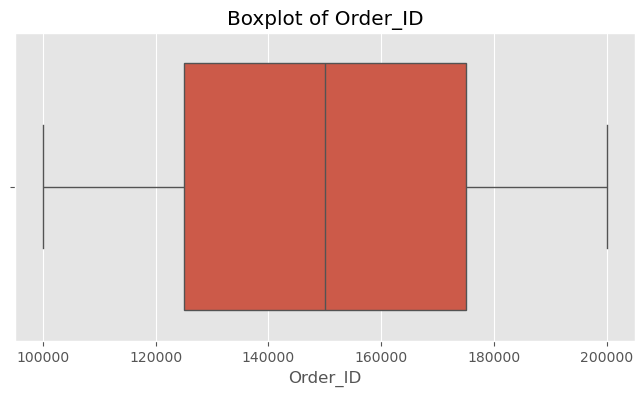

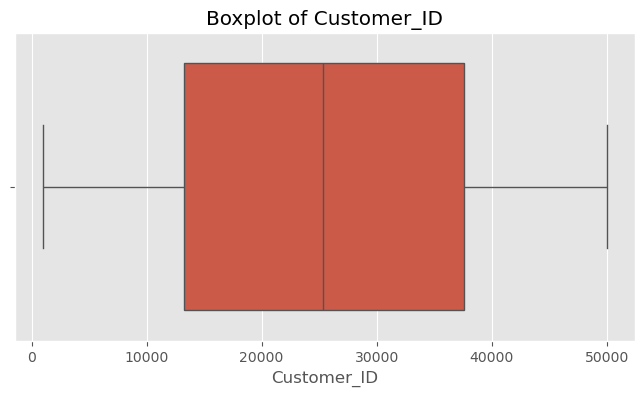

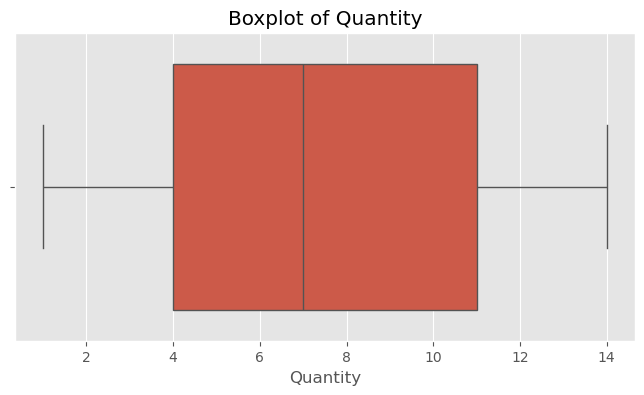

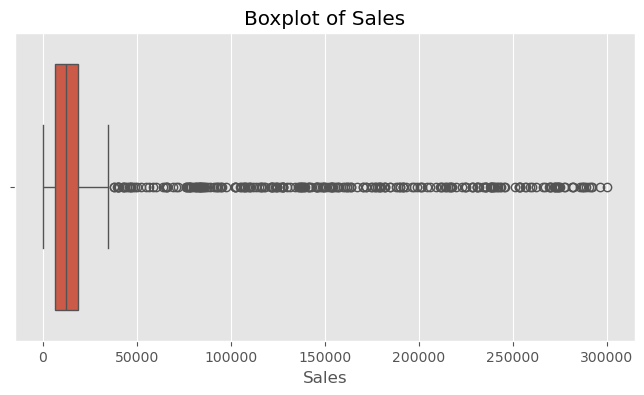

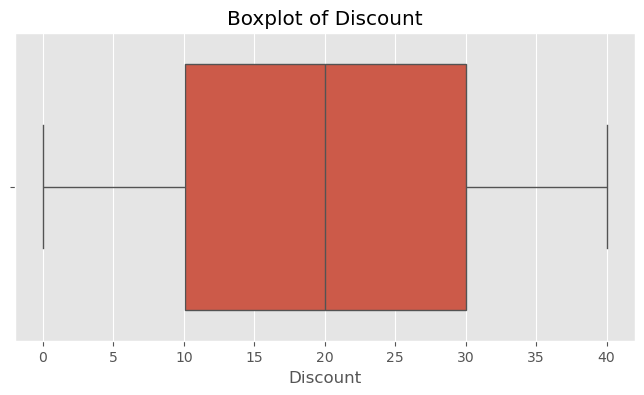

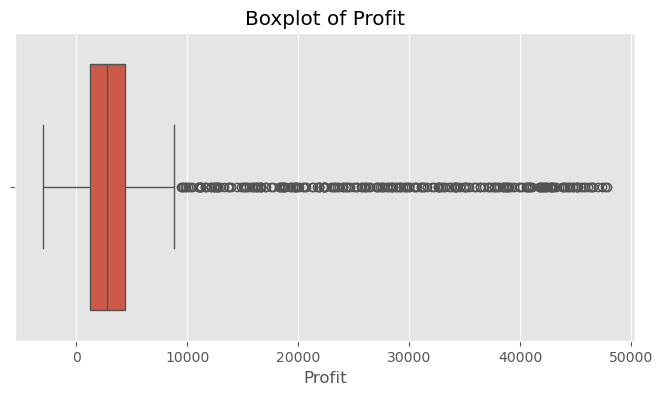

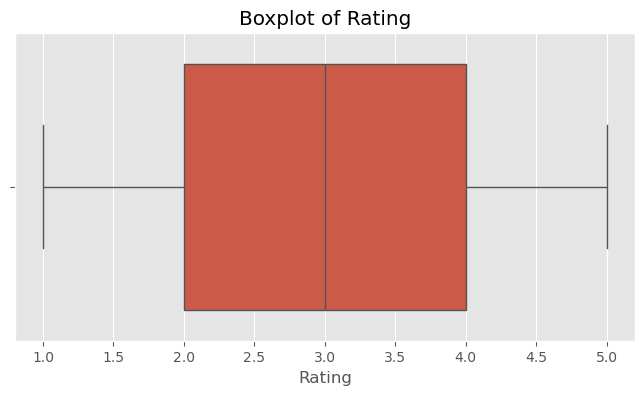

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [51]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower) | (data[column] > upper)]

    print(f"{column}: {len(outliers)} outliers")

In [53]:
for col in numerical_cols:
    detect_outliers_iqr(df, col)

Order_ID: 0 outliers
Customer_ID: 0 outliers
Quantity: 0 outliers
Sales: 264 outliers
Discount: 0 outliers
Profit: 237 outliers
Rating: 0 outliers


In [55]:
df_clean = df.copy()

for col in numerical_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

In [57]:
print("Original Shape :", df.shape)
print("After Removing Outliers :", df_clean.shape)

Original Shape : (100038, 13)
After Removing Outliers : (99747, 13)


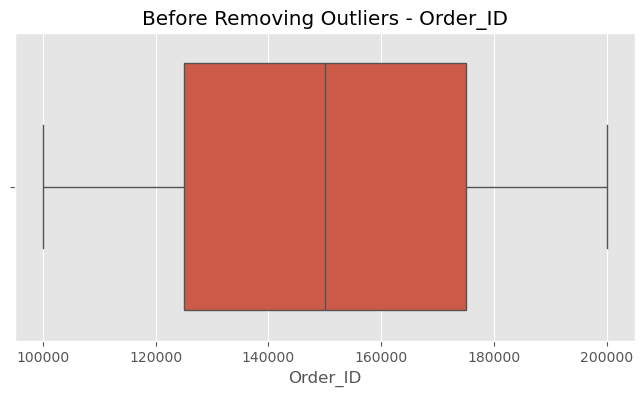

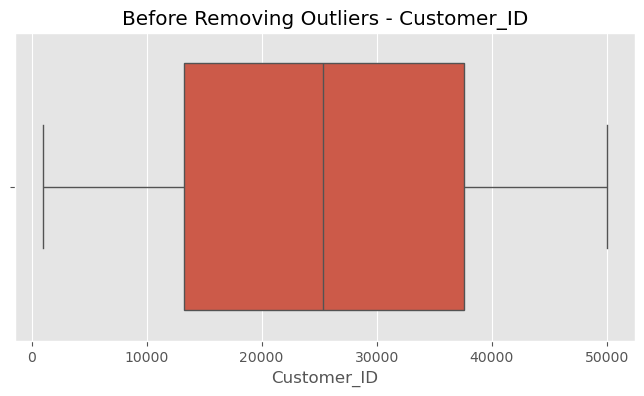

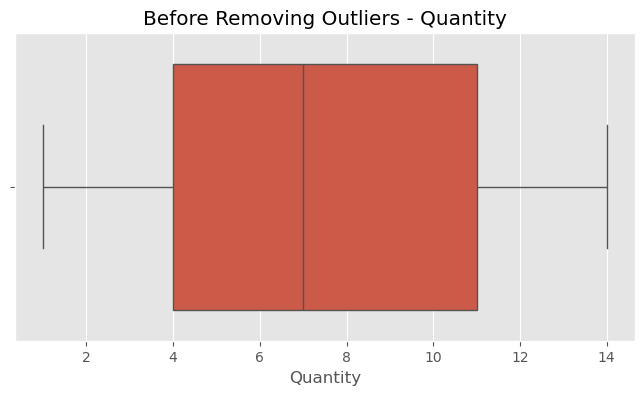

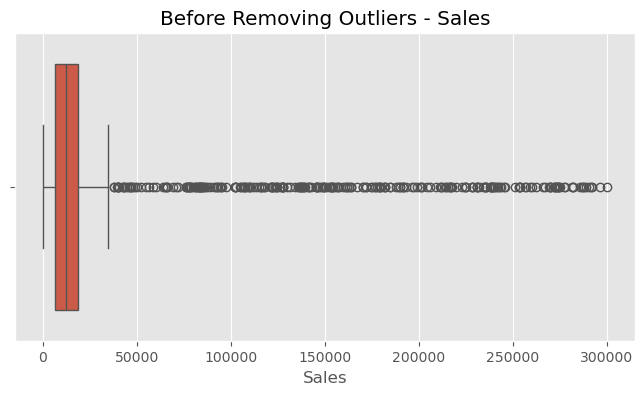

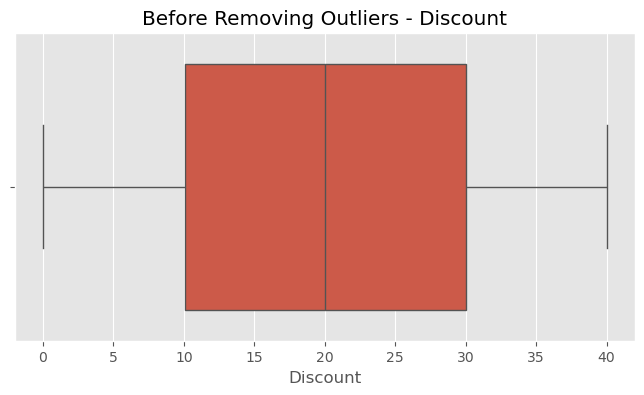

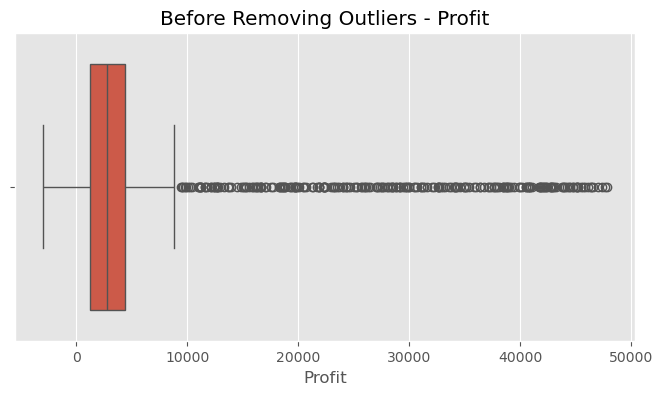

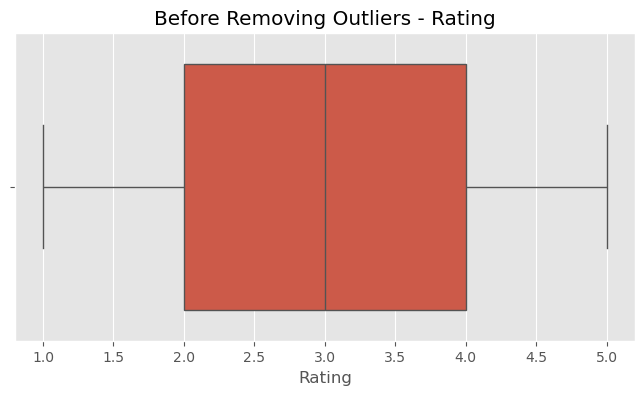

In [59]:
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Before Removing Outliers - {col}")
    plt.show()

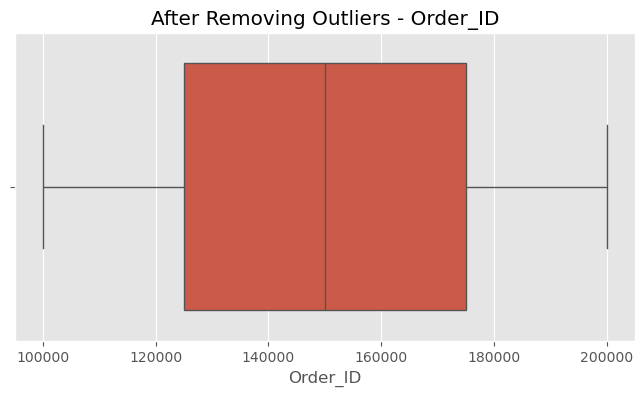

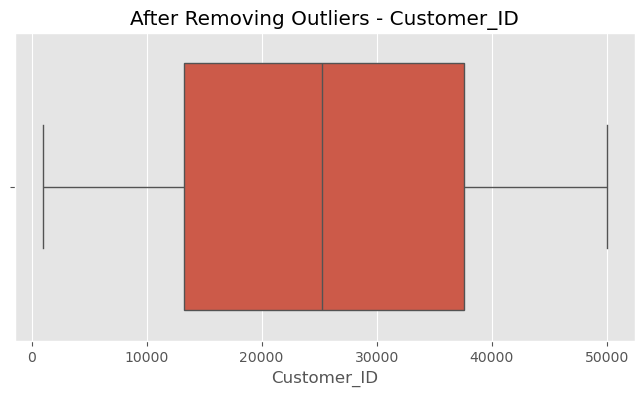

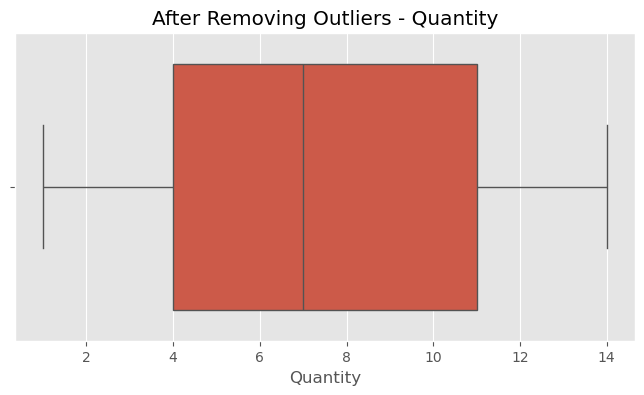

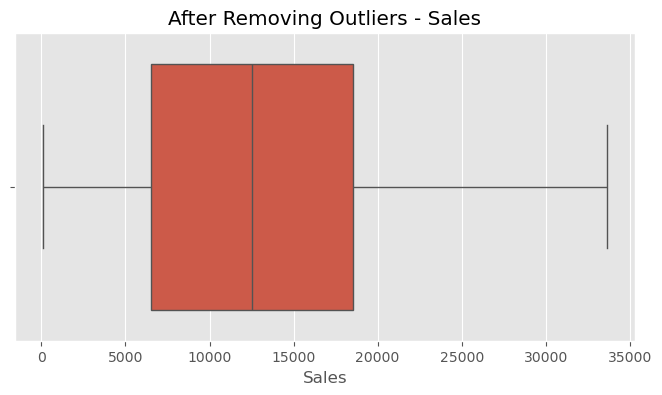

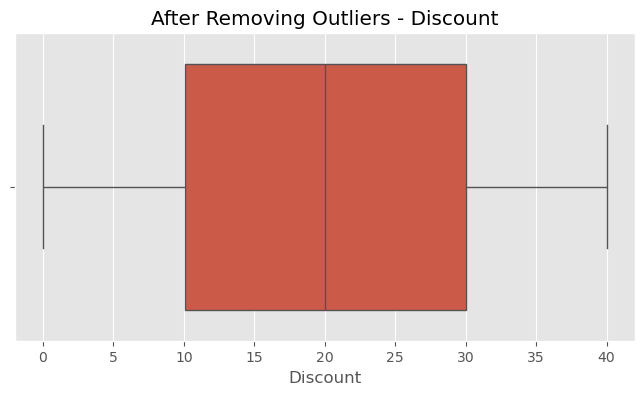

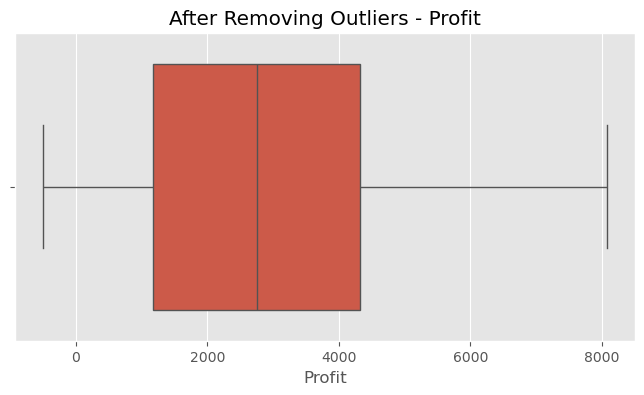

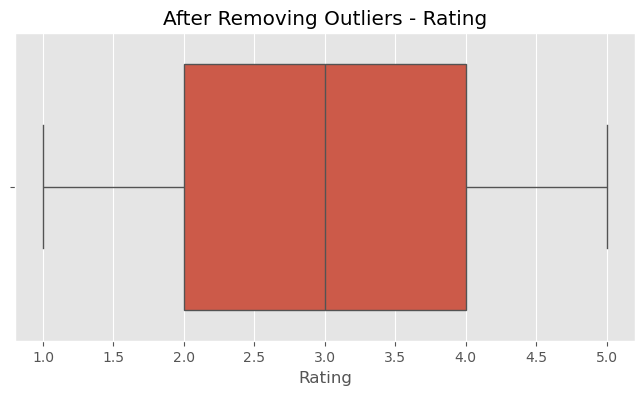

In [61]:
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_clean[col])
    plt.title(f"After Removing Outliers - {col}")
    plt.show()

In [63]:
df_clean.to_csv("~/PROJECT/Data_Cleaning_Visualization/data/cleaned_without_outliers.csv", index=False)

print("✅ Dataset saved successfully!")

✅ Dataset saved successfully!


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Use cleaned dataset
df = df_clean.copy()

In [67]:
print(df.head())

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

   Order_ID  Customer_ID Order_Date     Category   Region     City  \
0    100001        16795 2023-11-27       Beauty     West   Jaipur   
1    100002         1860 2024-07-27       Sports  Central   Nagpur   
2    100003        39158 2023-11-17  Electronics     East     Pune   
3    100004        45732 2023-09-14     Clothing    South  Kolkata   
4    100005        12284 2024-01-11    Furniture     East    Delhi   

  Customer_Type  Quantity     Sales  Discount   Profit Payment_Method  Rating  
0       Premium         6    652.74     39.15  4297.94           Cash     3.4  
1           New         3  19695.06     13.26  2806.84     Debit Card     3.1  
2           New         7   5025.52     16.61  1466.65    Net Banking     2.2  
3       Regular         4  20561.27     15.03   630.79     Debit Card     3.9  
4           New         1  12050.79     19.48  4540.40            Upi     3.7  

Shape: (99747, 13)

Columns:
Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Category', 'Region',

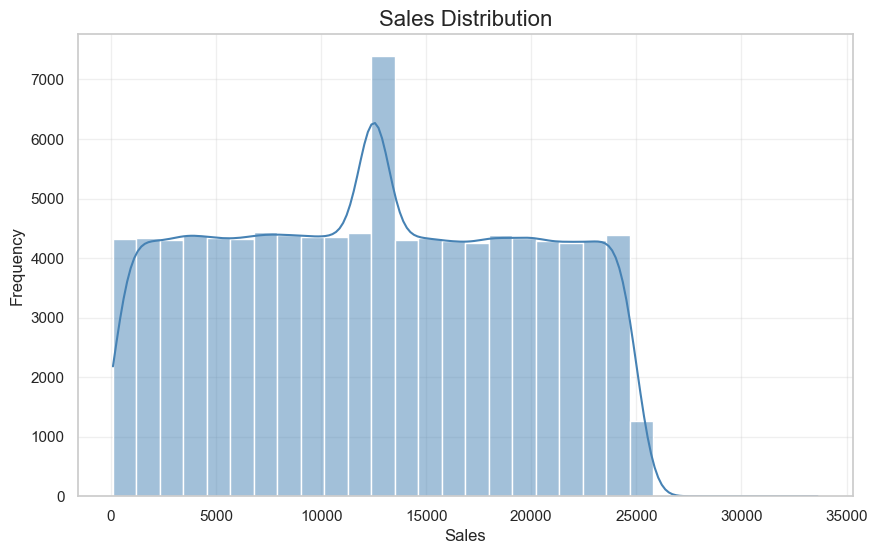

✅ sales_distribution.png saved successfully.


In [115]:
# -----------------------------
# Sales Distribution
# -----------------------------

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create images folder
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,6))

sns.histplot(df["Sales"], bins=30, kde=True, color="steelblue")

plt.title("Sales Distribution", fontsize=16)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

# Save chart
plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ sales_distribution.png saved successfully.")

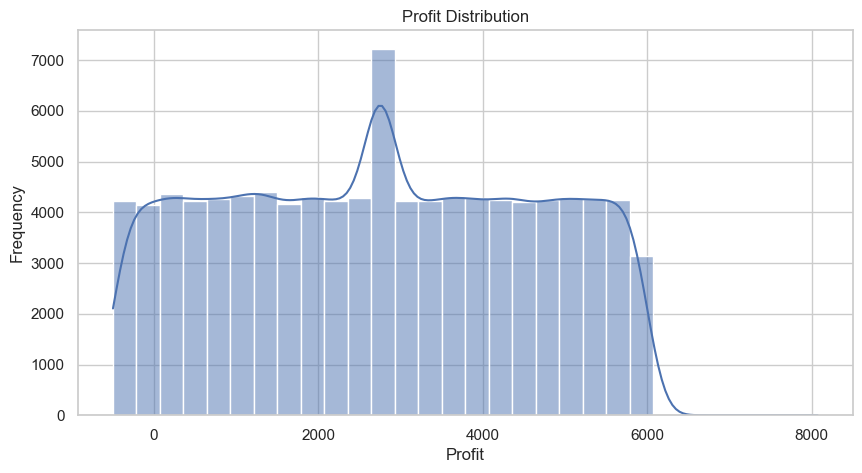

In [118]:
plt.figure(figsize=(10,5))

sns.histplot(df["Profit"], bins=30, kde=True)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.savefig("C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/profit_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

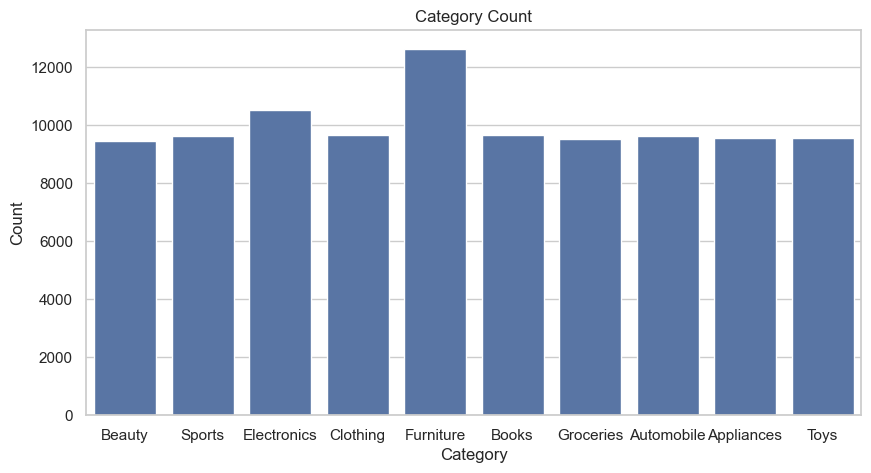

In [120]:
plt.figure(figsize=(10,5))

sns.countplot(x="Category", data=df)

plt.title("Category Count")
plt.xlabel("Category")
plt.ylabel("Count")

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/category_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

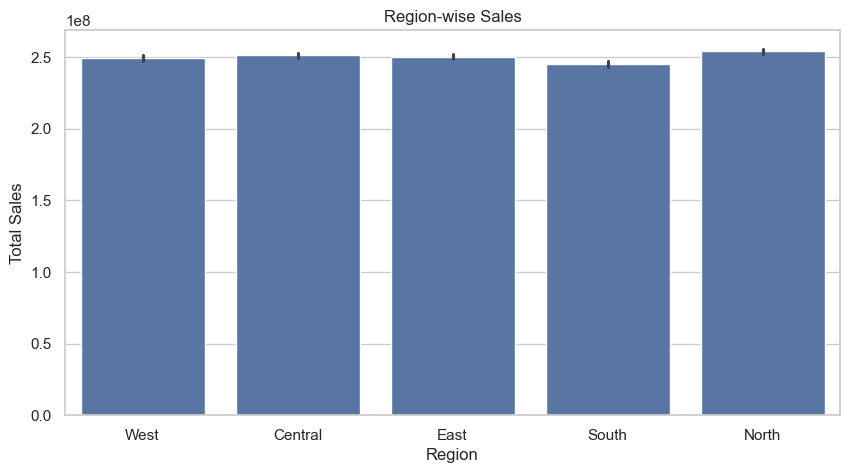

In [122]:
plt.figure(figsize=(10,5))

sns.barplot(x="Region", y="Sales", data=df, estimator=sum)

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/region_wise_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

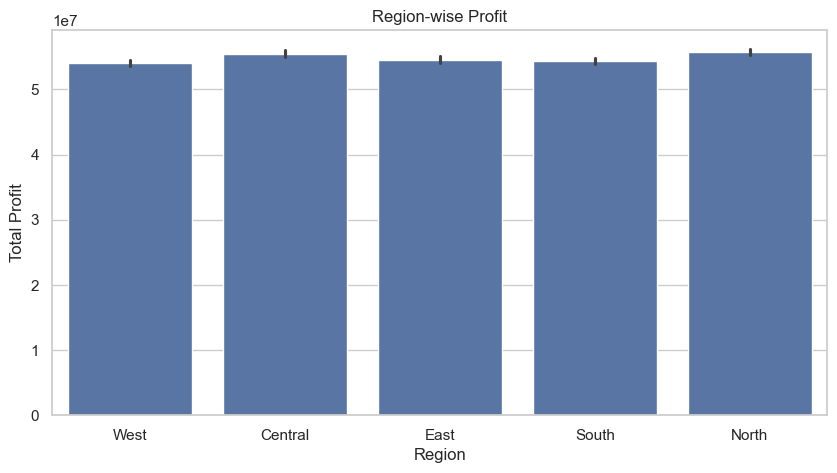

In [124]:
plt.figure(figsize=(10,5))

sns.barplot(x="Region", y="Profit", data=df, estimator=sum)

plt.title("Region-wise Profit")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/region_wise_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

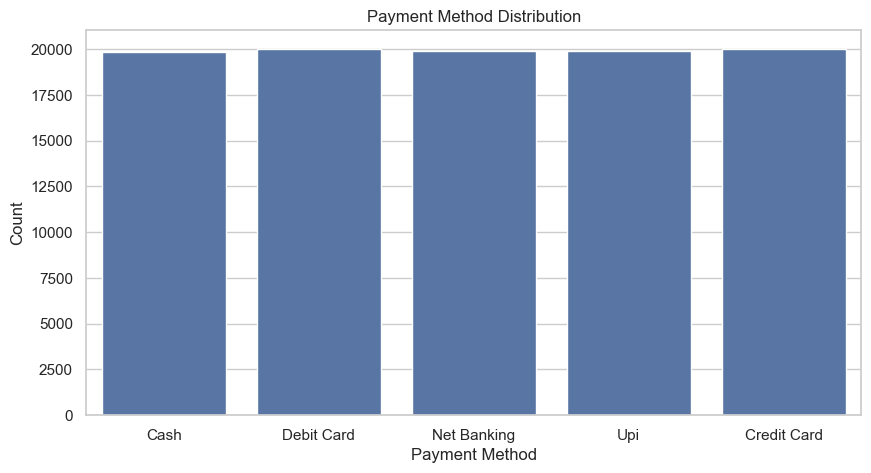

In [126]:
plt.figure(figsize=(10,5))

sns.countplot(x="Payment_Method", data=df)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/payment_method_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

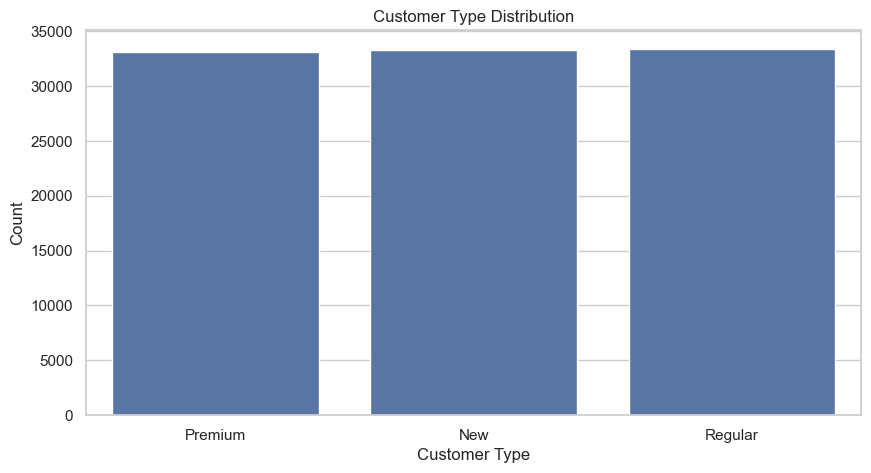

In [128]:
plt.figure(figsize=(10,5))

sns.countplot(x="Customer_Type", data=df)

plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Count")

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/customer_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

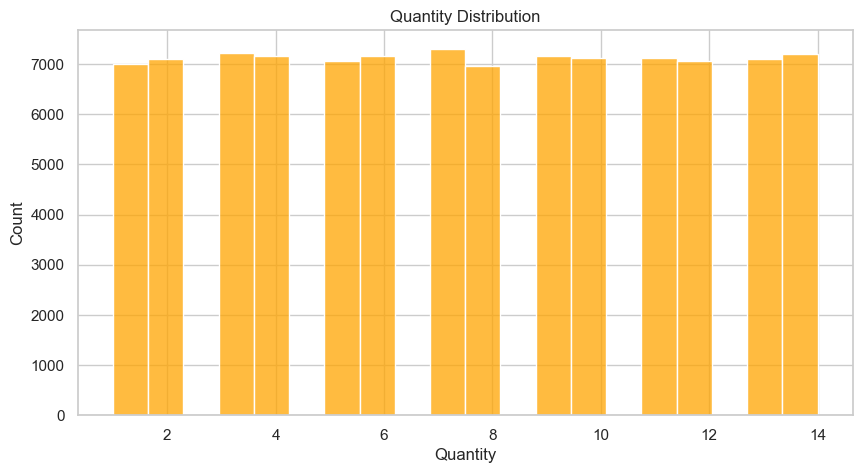

In [83]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Quantity"],
    bins=20,
    color="orange"
)

plt.title("Quantity Distribution")

plt.show()

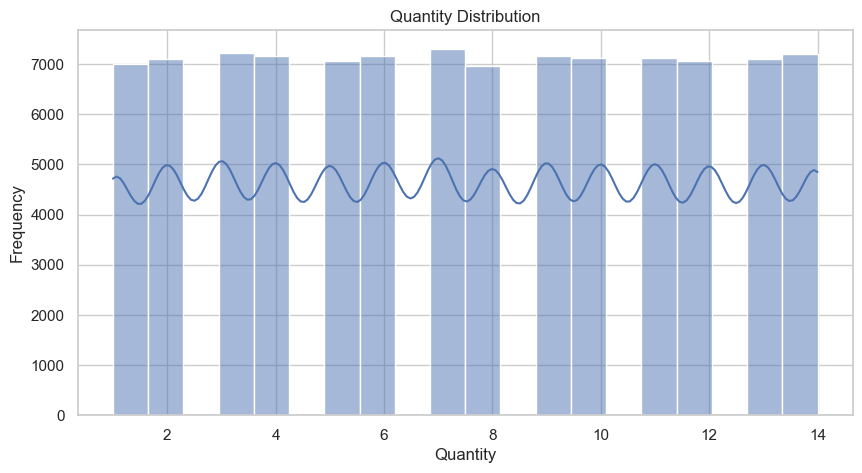

In [130]:
plt.figure(figsize=(10,5))

sns.histplot(df["Quantity"], bins=20, kde=True)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/quantity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

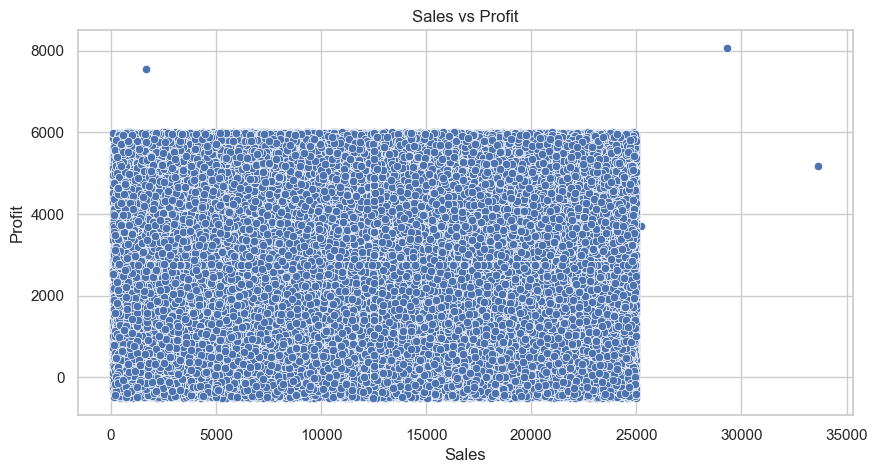

In [132]:
plt.figure(figsize=(10,5))

sns.scatterplot(x="Sales", y="Profit", data=df)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/sales_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

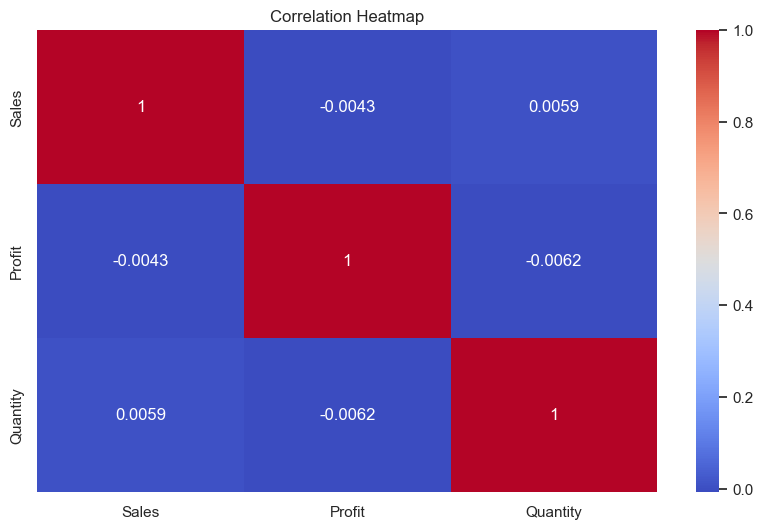

In [134]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[["Sales", "Profit", "Quantity"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

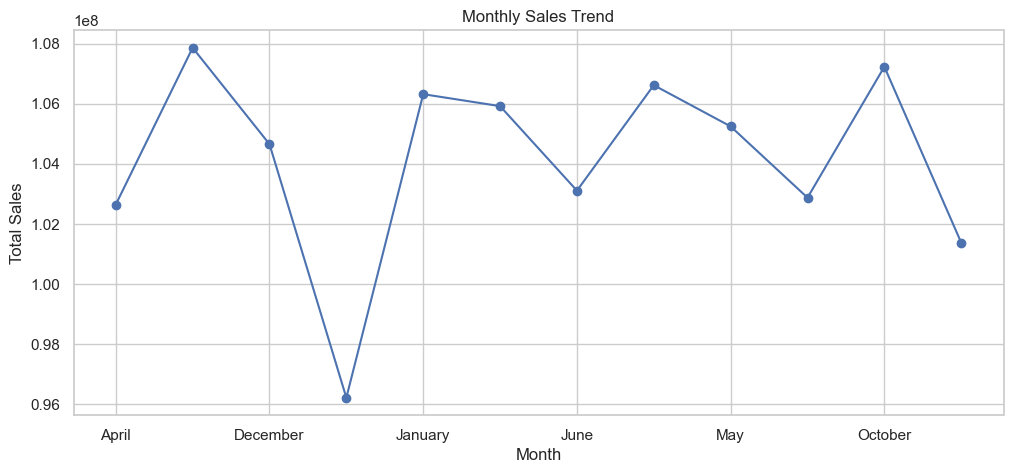

In [136]:
plt.figure(figsize=(12,5))

monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

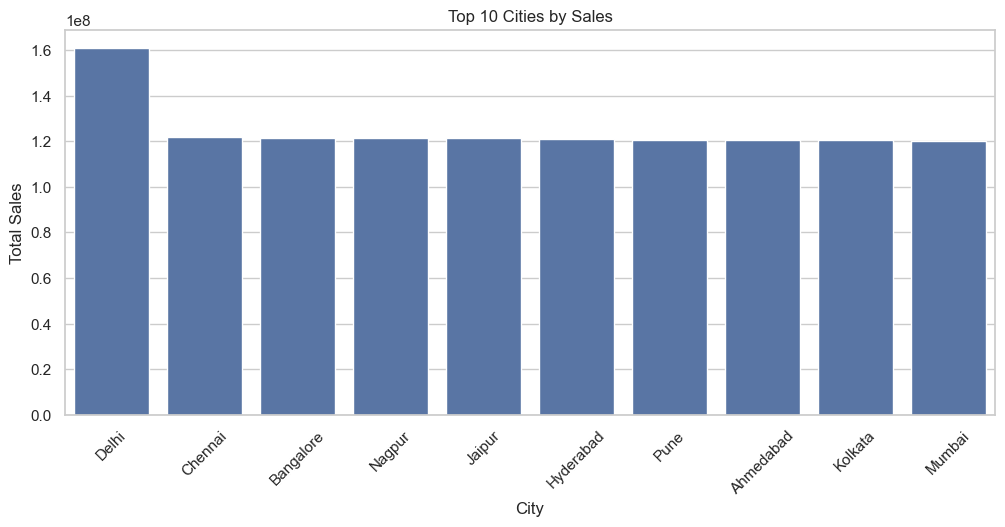

In [138]:
plt.figure(figsize=(12,5))

top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_cities.index, y=top_cities.values)

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/top_10_cities_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

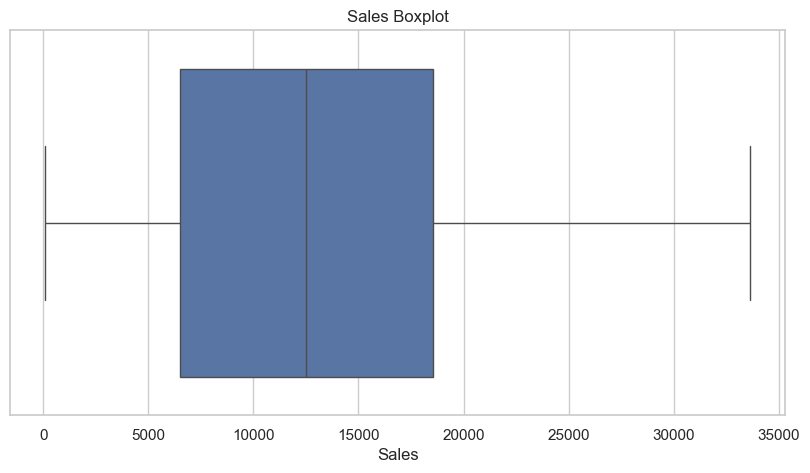

In [95]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Sales"])

plt.title("Sales Boxplot")

plt.show()

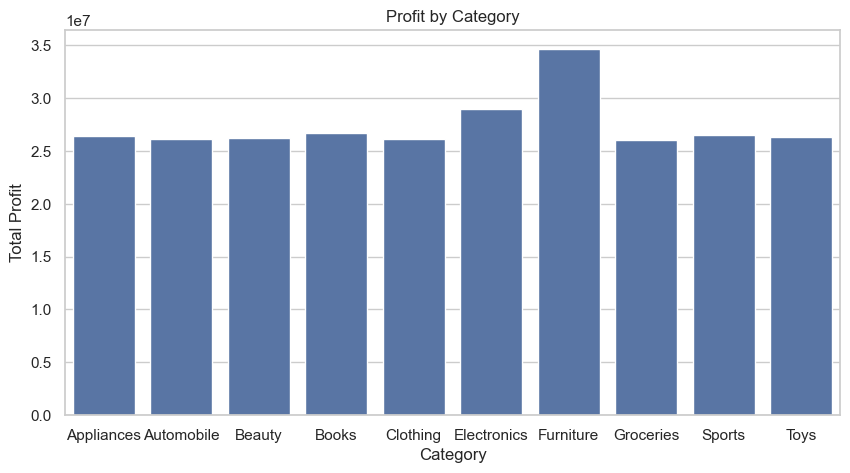

In [140]:
plt.figure(figsize=(10,5))

category_profit = df.groupby("Category")["Profit"].sum().reset_index()

sns.barplot(x="Category", y="Profit", data=category_profit)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/profit_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

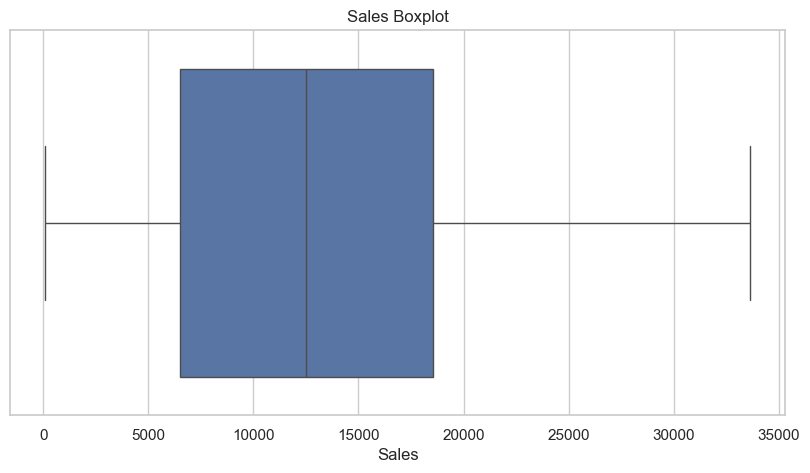

In [142]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Sales"])

plt.title("Sales Boxplot")
plt.xlabel("Sales")

plt.savefig(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/images/sales_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Insights

- Sales are unevenly distributed, with a few high-value transactions.
- Profit varies across products, indicating differences in profitability.
- Some product categories contribute more to total sales than others.
- Sales and Profit have a positive relationship.
- A few cities generate the highest sales.
- Sales and profits differ across regions.
- Most customers prefer a limited number of payment methods.
- Most orders contain a small quantity of items.

# Conclusion

This project demonstrates a complete data analysis workflow using Python.

The dataset was cleaned by handling missing values, removing duplicates, and treating outliers. Exploratory Data Analysis (EDA) was performed using 15 visualizations to understand sales, profit, customer behavior, and regional performance.

The cleaned dataset and visualizations provide valuable business insights and can be used for future reporting, dashboard creation, and predictive analytics.

In [146]:
df.to_csv(
    "C:/Users/Shree/PROJECT/Data_Cleaning_Visualization/data/cleaned_retail_sales.csv",
    index=False
)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!
